# Tutorial 01 — Getting Started with `awesomepkf`

This notebook introduces the **Pairwise Kalman Filter (PKF)** framework and its variants:

| Filter | Class | Description |
|--------|-------|-------------|
| Linear PKF | `Linear_PKF` | Exact Kalman filter for linear pairwise models |
| EPKF | `NonLinear_EPKF` | Extended (first-order) PKF for nonlinear models |
| UPKF | `NonLinear_UPKF` | Unscented (sigma-point) PKF |
| UKF  | `NonLinear_UKF`  | Unscented Kalman Filter (adapted for pairwise observation models) |
| PPF  | `NonLinear_PPF`  | Pairwise Particle Filter |
| PF   | `NonLinear_PF`   | Bootstrap Particle Filter |

**What you will learn:**
- List and explore available models
- Create a filter and run it on simulated data
- Visualize state estimates with confidence envelopes
- Compute error metrics (MSE, NEES, NIS)
- Compare Linear PKF, EPKF, and UPKF on the same data

**Run from the project root:**
```bash
jupyter notebook ipynb/tutorial_01_getting_started.ipynb
```

## Setup

In [10]:
import sys
import os

# Add project root to path (needed when running from ipynb/ subdirectory)
sys.path.insert(0, os.path.abspath(".."))

import numpy as np
import matplotlib.pyplot as plt
import pandas as pd

# awesomepkf public API
from prg import (
    Linear_PKF,
    NonLinear_EPKF,
    NonLinear_UPKF,
    ParamLinear,
    ParamNonLinear,
    ModelFactoryLinear,
    ModelFactoryNonLinear,
    __version__,
)

print(f"awesomepkf version: {__version__}")

awesomepkf version: 0.1.0


---
## 1. Available Models

In [11]:
linear_models = sorted(ModelFactoryLinear.list_models())
nonlinear_models = sorted(ModelFactoryNonLinear.list_models())

print("Linear models:")
for m in linear_models:
    print(f"  {m}")

print()
print("Nonlinear models:")
for m in nonlinear_models:
    print(f"  {m}")

Linear models:
  model_x1_y1_AQ_augmented
  model_x1_y1_AQ_classic
  model_x1_y1_AQ_pairwise
  model_x1_y1_Sigma_pairwise
  model_x2_y2_AQ_augmented
  model_x2_y2_AQ_classic
  model_x2_y2_AQ_pairwise
  model_x2_y2_Sigma_pairwise
  model_x3_y1_AQ_augmented
  model_x3_y1_AQ_classic
  model_x3_y1_AQ_pairwise
  model_x3_y1_Sigma_pairwise

Nonlinear models:
  model_x1_y1_Cubique_classic
  model_x1_y1_ExpSaturant_classic
  model_x1_y1_Gordon_classic
  model_x1_y1_Sinus_classic
  model_x1_y1_augmented
  model_x1_y1_pairwise
  model_x2_y1_Rapport_classic
  model_x2_y1_augmented
  model_x2_y1_classic
  model_x2_y1_pairwise
  model_x2_y2_augmented
  model_x2_y2_pairwise


Model names follow the convention `model_x{d_x}_y{d_y}_{noise_type}_{structure}` where:
- `d_x` / `d_y` — state and observation dimensions
- `AQ` — parametrized via matrices A (transition) and Q (noise)
- `classic` — standard state-space form (no feedback)
- `pairwise` — explicit cross-feedback between state and observations
- `augmented` — augmented state vector (state + noise)

---
## 2. Exploring a Linear Model

We use `model_x2_y2_AQ_classic`: 2D state, 2D observations, classic structure.

In [12]:
model = ModelFactoryLinear.create("model_x2_y2_AQ_classic")

params = model.get_params()
dim_x = params["dim_x"]
dim_y = params["dim_y"]

print(f"Model: {model}")
print(f"State dimension  dim_x = {dim_x}")
print(f"Obs.  dimension  dim_y = {dim_y}")
print(f"Model type: pairwise={params['pairwiseModel']}, augmented={params['augmented']}")
print()
print("Transition matrix A (shape", params['A'].shape, "):")
print(np.round(params['A'], 4))
print()
print("Joint noise covariance mQ (shape", params['mQ'].shape, "):")
print(np.round(params['mQ'], 4))
print()
print("Initial state mean mz0:", params['mz0'].flatten())
print("Initial state cov  Pz0 (diagonal):", np.diag(params['Pz0']))

Model: Model_x2_y2_AQ_classic(dim_x=2, dim_y=2, type=linear_AmQ)
State dimension  dim_x = 2
Obs.  dimension  dim_y = 2
Model type: pairwise=False, augmented=False

Transition matrix A (shape (4, 4) ):
[[0.6   0.1   0.    0.   ]
 [0.1   0.5   0.    0.   ]
 [0.38  0.16  0.    0.   ]
 [0.16  0.365 0.    0.   ]]

Joint noise covariance mQ (shape (4, 4) ):
[[0.1868 0.     0.     0.    ]
 [0.     0.1577 0.     0.    ]
 [0.     0.     0.103  0.    ]
 [0.     0.     0.     0.0606]]

Initial state mean mz0: [-0.65743106  1.3924692  -0.50628911  1.56994913]
Initial state cov  Pz0 (diagonal): [0.05691915 0.12541559 0.08584963 0.06584815]


The `mQ` matrix is the joint (state + observation) noise covariance. It decomposes as:

$$
\mathbf{Q}_{\text{joint}} = \begin{bmatrix} Q_{xx} & M_{xy} \\ M_{yx} & R_{yy} \end{bmatrix}
$$

where `Q_xx` is the process noise, `R_yy` the observation noise, and `M_xy` the cross-correlation.

In [13]:
mQ = params["mQ"]
Q_xx = mQ[:dim_x, :dim_x]   # Process noise
R_yy = mQ[dim_x:, dim_x:]   # Observation noise
M_xy = mQ[:dim_x, dim_x:]   # Cross-correlation

print("Q_xx (process noise):")    ; print(np.round(Q_xx, 4))
print()
print("R_yy (observation noise):") ; print(np.round(R_yy, 4))
print()
print("M_xy (cross-correlation):") ; print(np.round(M_xy, 4))

Q_xx (process noise):
[[0.1868 0.    ]
 [0.     0.1577]]

R_yy (observation noise):
[[0.103  0.    ]
 [0.     0.0606]]

M_xy (cross-correlation):
[[0. 0.]
 [0. 0.]]


---
## 3. Running the Linear PKF

The workflow has three steps:
1. Create a `ParamLinear` object from model parameters
2. Instantiate `Linear_PKF` with the parameters and a random seed
3. Call `process_N_data(N)` to simulate data and run the filter

In [14]:
N = 300      # Number of time steps
SEED = 42    # For reproducibility

# Step 1 — Build parameters
p = params.copy()
dim_x = p.pop("dim_x")
dim_y = p.pop("dim_y")
param = ParamLinear(verbose=0, dim_x=dim_x, dim_y=dim_y, **p)

# Step 2 — Instantiate filter
pkf = Linear_PKF(param, sKey=SEED)

# Step 3 — Simulate data and run filter
results = pkf.process_N_data(N=N)

print(f"Number of results: {len(results)}  (= N+1: initial prediction + N updates)")
print(f"Each result is a tuple of length {len(results[0])}: (k, x_true, y_obs, X_predict, X_update)")
print(f"  results[0]: k={results[0][0]}, X_update={results[0][4]}  ← None at k=0 (prediction only)")
print(f"  results[1]: k={results[1][0]}, X_update shape={results[1][4].shape}")

Number of results: 301  (= N+1: initial prediction + N updates)
Each result is a tuple of length 5: (k, x_true, y_obs, X_predict, X_update)
  results[0]: k=0, X_update=[[-0.77129738]
 [ 1.21864504]]  ← None at k=0 (prediction only)
  results[1]: k=1, X_update shape=(2, 1)


---
## 4. Extracting Results

Results can be accessed two ways: from the returned list of tuples, or from `pkf.history`.

In [15]:
# --- From the results list ---
# Note: k=0 has X_update=None (prediction-only step)
k_arr      = np.array([r[0] for r in results])                         # (N+1,)
x_true_arr = np.array([r[1].flatten() for r in results])               # (N+1, dim_x)
y_obs_arr  = np.array([r[2].flatten() for r in results])               # (N+1, dim_y)
x_pred_arr = np.array([r[3].flatten() for r in results])               # (N+1, dim_x)
x_upd_arr  = np.array([r[4].flatten() for r in results if r[4] is not None])  # (N, dim_x)

print(f"x_true_arr shape : {x_true_arr.shape}")
print(f"x_pred_arr shape : {x_pred_arr.shape}")
print(f"x_upd_arr  shape : {x_upd_arr.shape}")

x_true_arr shape : (301, 2)
x_pred_arr shape : (301, 2)
x_upd_arr  shape : (301, 2)


In [16]:
# --- From the history DataFrame ---
df = pkf.history.as_dataframe()
print("History DataFrame columns:", list(df.columns))
print(f"Number of rows: {len(df)}")
print()
print("First row (k=0, prediction only):")
print(f"  xkp1          = {df['xkp1'].iloc[0].flatten()}")
print(f"  Xkp1_predict  = {df['Xkp1_predict'].iloc[0].flatten()}")
print(f"  Xkp1_update   = {df['Xkp1_update'].iloc[0]}   ← None at k=0")
print()
print("Second row (k=1, first update):")
print(f"  Xkp1_update   = {df['Xkp1_update'].iloc[1].flatten()}")

History DataFrame columns: ['k', 'xkp1', 'ykp1', 'Xkp1_predict', 'PXXkp1_predict', 'ikp1', 'Skp1', 'Kkp1', 'Xkp1_update', 'PXXkp1_update']
Number of rows: 301

First row (k=0, prediction only):
  xkp1          = [-0.69531929  1.42474026]
  Xkp1_predict  = [0. 0.]
  Xkp1_update   = [[-0.77129738]
 [ 1.21864504]]   ← None at k=0

Second row (k=1, first update):
  Xkp1_update   = [-0.40108084  0.48522224]


---
## 5. Visualizing State Estimates

### 5a. Using `history.plot()` (built-in)

The `HistoryTracker.plot()` method overlays multiple columns on per-component subplots, with optional ±2σ confidence envelopes.

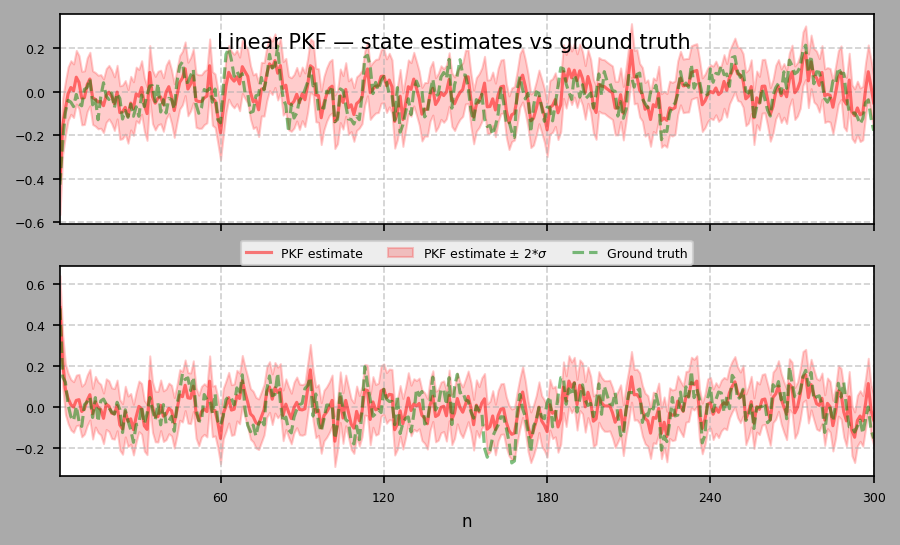

In [17]:
fig, axes = pkf.history.plot(
    title="Linear PKF — state estimates vs ground truth",
    list_param=["Xkp1_update", "xkp1"],
    list_label=["PKF estimate", "Ground truth"],
    list_covar=["PXXkp1_update", None],   # ±2σ envelope for the estimate only
    window={"xmin": 1, "xmax": N + 1},   # skip k=0 (no update)
    show=True,
)

### 5b. Manual plotting with matplotlib

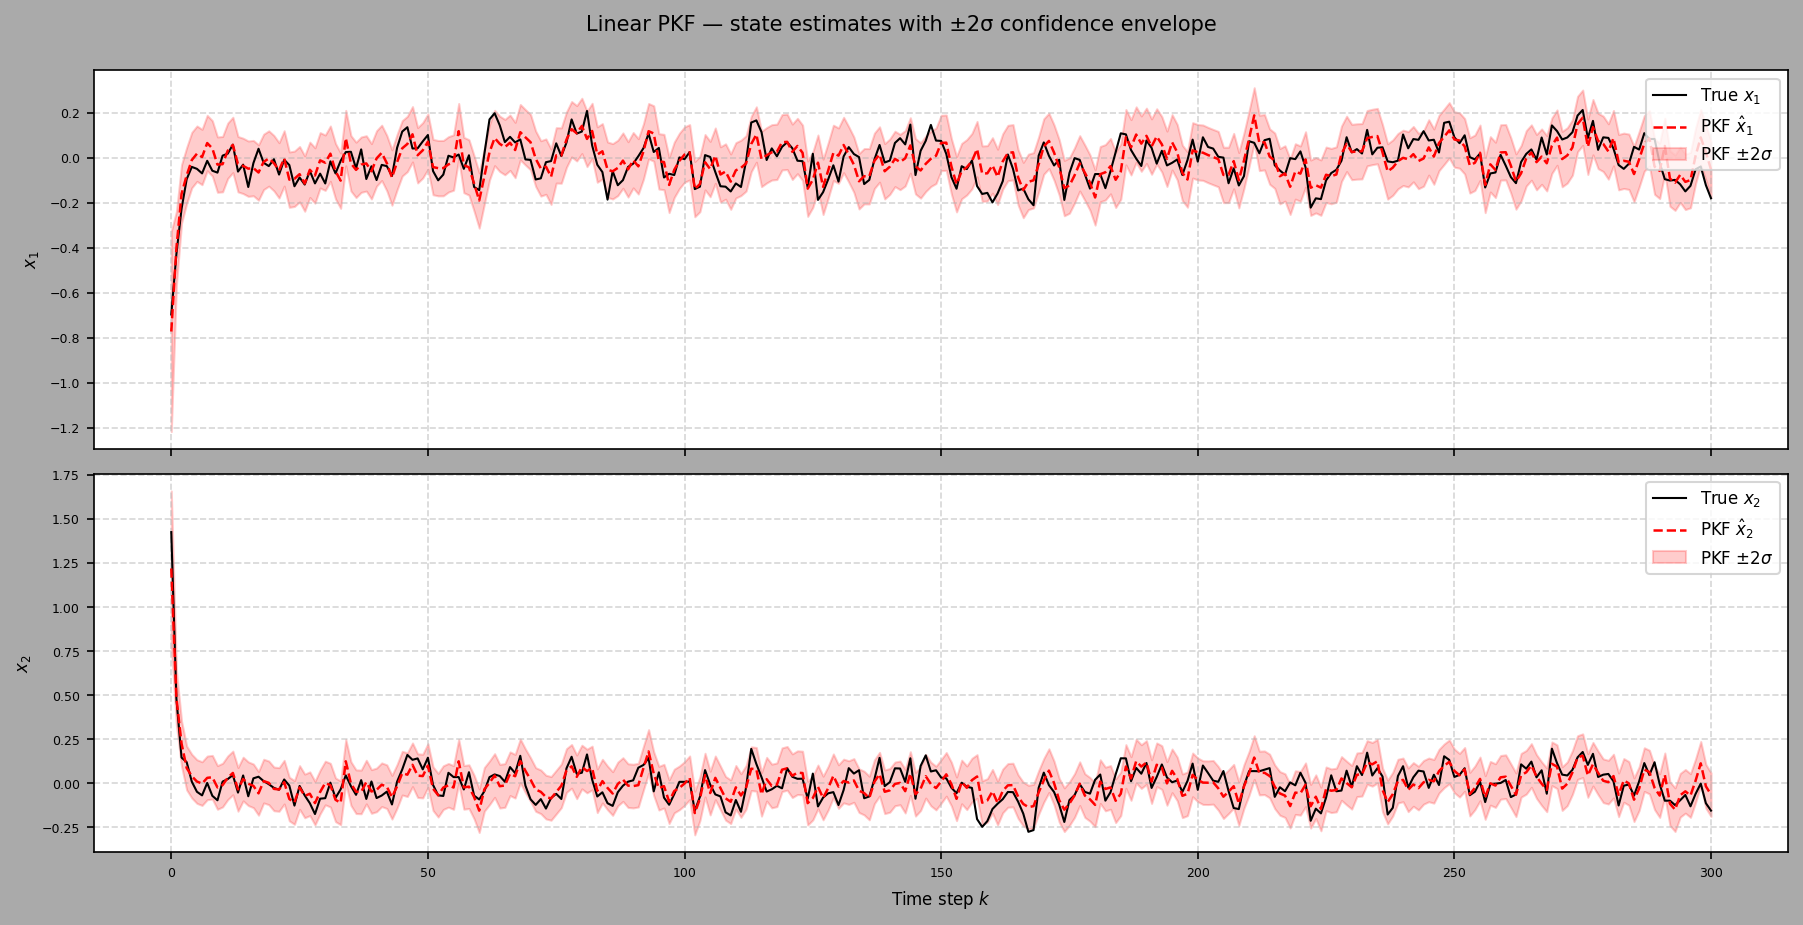

In [18]:
# Extract covariance diagonal (std dev) from history
P_upd_list = [v for v in df["PXXkp1_update"] if v is not None]
P_upd_arr  = np.array(P_upd_list)                                # (M, dim_x, dim_x)
std_upd    = np.sqrt(np.array([[p[i, i] for i in range(dim_x)] for p in P_upd_arr]))  # (M, dim_x)

# Align time axis and ground truth with x_upd_arr (which may include k=0)
M = len(x_upd_arr)
t = np.arange(M)
x_true_plot = x_true_arr[:M]

fig, axes = plt.subplots(dim_x, 1, figsize=(12, 3 * dim_x), sharex=True)
if dim_x == 1:
    axes = [axes]

for i in range(dim_x):
    ax = axes[i]
    ax.plot(t, x_true_plot[:, i],  color="black",  lw=1.0, label=f"True $x_{i+1}$")
    ax.plot(t, x_upd_arr[:, i],    color="C0",     lw=1.2, label=f"PKF $\\hat{{x}}_{i+1}$")
    ax.fill_between(
        t,
        x_upd_arr[:, i] - 2 * std_upd[:, i],
        x_upd_arr[:, i] + 2 * std_upd[:, i],
        color="C0", alpha=0.20, label=r"PKF $\pm 2\sigma$",
    )
    ax.set_ylabel(f"$x_{i+1}$")
    ax.legend(loc="upper right", fontsize=8)
    ax.grid(True, linestyle="--", alpha=0.5)

axes[-1].set_xlabel("Time step $k$")
fig.suptitle("Linear PKF — state estimates with ±2σ confidence envelope", y=1.01)
plt.tight_layout()
plt.show()

### 5c. Innovations

The **innovation** $i_k = y_k - \hat{y}_{k|k-1}$ measures how much the observation surprises the filter. Well-calibrated filters produce zero-mean innovations.

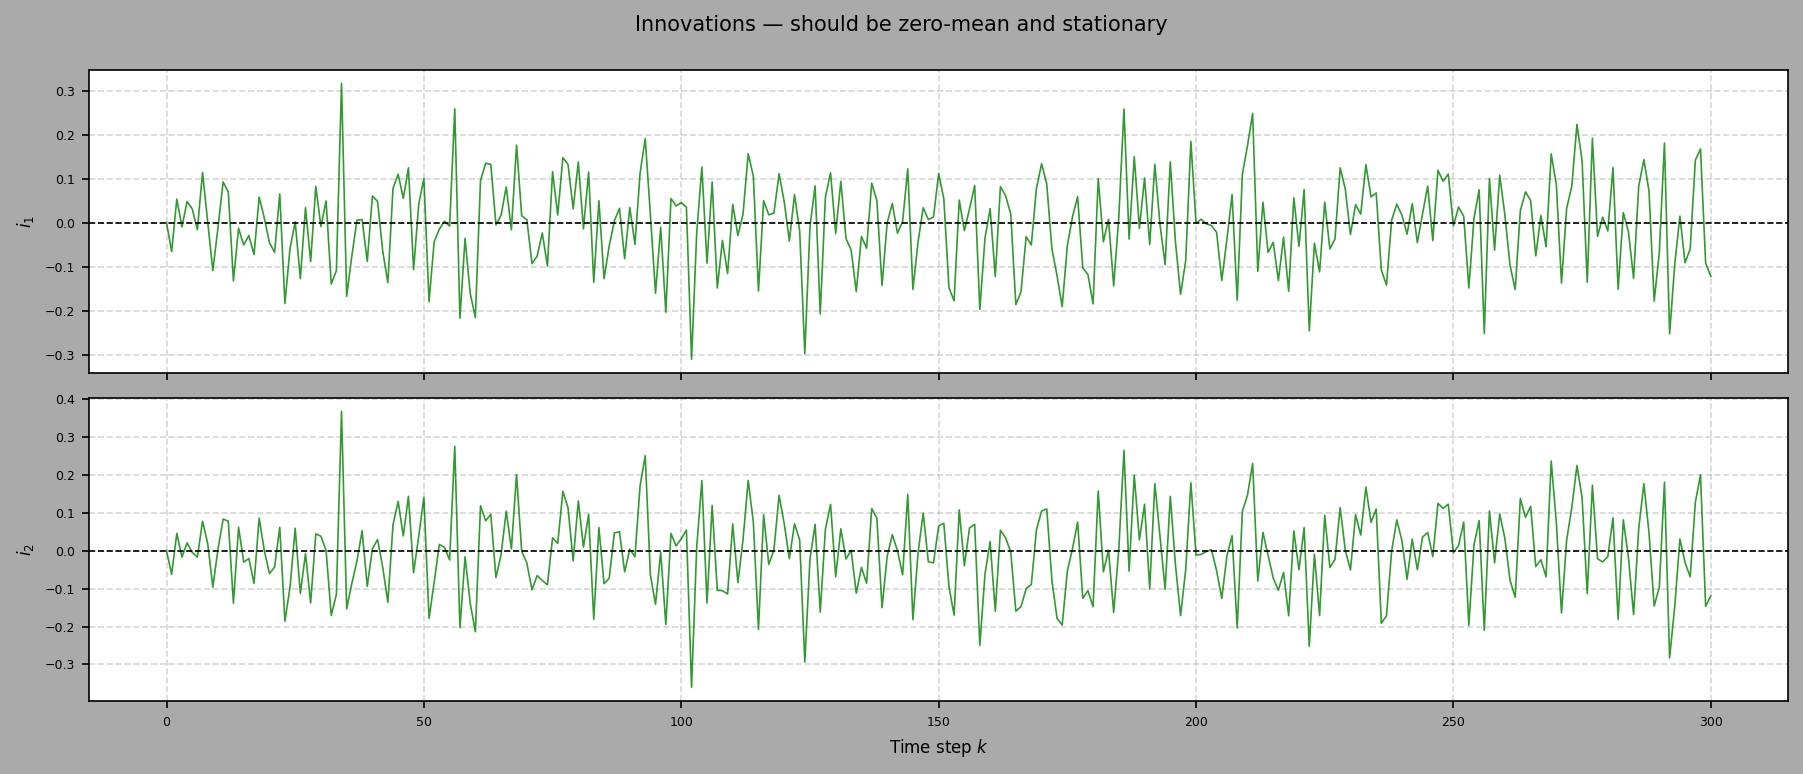

Innovation means: [-0.0046 -0.0047]
Innovation stds:  [0.104  0.1117]


In [19]:
innov_list = [v for v in df["ikp1"] if v is not None]
innov_arr  = np.array([v.flatten() for v in innov_list])   # (N, dim_y)

fig, axes = plt.subplots(dim_y, 1, figsize=(12, 2.5 * dim_y), sharex=True)
if dim_y == 1:
    axes = [axes]

for j in range(dim_y):
    axes[j].plot(innov_arr[:, j], color="C1", lw=0.8, alpha=0.8)
    axes[j].axhline(0, color="black", lw=0.8, linestyle="--")
    axes[j].set_ylabel(f"$i_{j+1}$")
    axes[j].grid(True, linestyle="--", alpha=0.5)

axes[-1].set_xlabel("Time step $k$")
fig.suptitle("Innovations — should be zero-mean and stationary", y=1.01)
plt.tight_layout()
plt.show()

print("Innovation means:", np.round(innov_arr.mean(axis=0), 4))
print("Innovation stds: ", np.round(innov_arr.std(axis=0), 4))

---
## 6. Error Metrics

Three standard metrics are computed:

| Metric | Formula | Interpretation |
|--------|---------|----------------|
| **MSE** | $\frac{1}{N d_x}\sum_{k,i}(x_{k,i} - \hat{x}_{k,i})^2$ | Lower is better |
| **NEES** | $\frac{1}{N}\sum_k \tilde{x}_k^\top P_k^{-1} \tilde{x}_k$ | Should be ≈ $d_x$ for well-calibrated filter |
| **NIS**  | $\frac{1}{N}\sum_k i_k^\top S_k^{-1} i_k$ | Should be ≈ $d_y$ for well-calibrated filter |

A NEES/dim_x ratio between 0.5 and 2.0 is generally considered well-calibrated.

In [20]:
# Using history.compute_errors — computes MSE, NEES, NIS
# verbose must be > 0 to display the report automatically
pkf_verbose = Linear_PKF(param, sKey=SEED)
pkf_verbose.verbose = 1
pkf_verbose.history.verbose = 1
_ = pkf_verbose.process_N_data(N=N)

pkf_verbose.history.compute_errors(
    model=pkf_verbose,
    ListeA=["xkp1"],
    ListeB=["Xkp1_update"],
    ListeC=["PXXkp1_update"],
    ListeD=["ikp1"],
    ListeE=["Skp1"],
)

xkp1 vs Xkp1_update  
┏━━━━━━━━━━━┳━━━━━━━━┓
┃ Field     ┃ Value  ┃
┡━━━━━━━━━━━╇━━━━━━━━┩
│ mse_total │ 0.0039 │
│ mae_total │ 0.0496 │
│ nees_mean │ 1.9482 │
│ nis_mean  │ 1.9270 │
└───────────┴────────┘

In [21]:
# Manual computation from the extracted arrays
# x_upd_arr has M entries (M = N or N+1 depending on filter internals)
M = len(x_upd_arr)
errors = x_true_arr[:M] - x_upd_arr   # shape (M, dim_x)
mse    = float(np.mean(errors ** 2))
mae    = float(np.mean(np.abs(errors)))

# NEES per step: e_k^T P_k^{-1} e_k
nees_steps = np.array([
    float(errors[k] @ np.linalg.inv(P_upd_arr[k]) @ errors[k])
    for k in range(M)
])
nees_mean = float(np.mean(nees_steps))

print(f"MSE  = {mse:.6f}")
print(f"MAE  = {mae:.6f}")
print(f"NEES = {nees_mean:.4f}  (expected ≈ {dim_x} for well-calibrated filter)")
print(f"NEES/dim_x = {nees_mean/dim_x:.4f}  (expected ≈ 1.0)")

MSE  = 0.003938
MAE  = 0.049590
NEES = 1.9482  (expected ≈ 2 for well-calibrated filter)
NEES/dim_x = 0.9741  (expected ≈ 1.0)


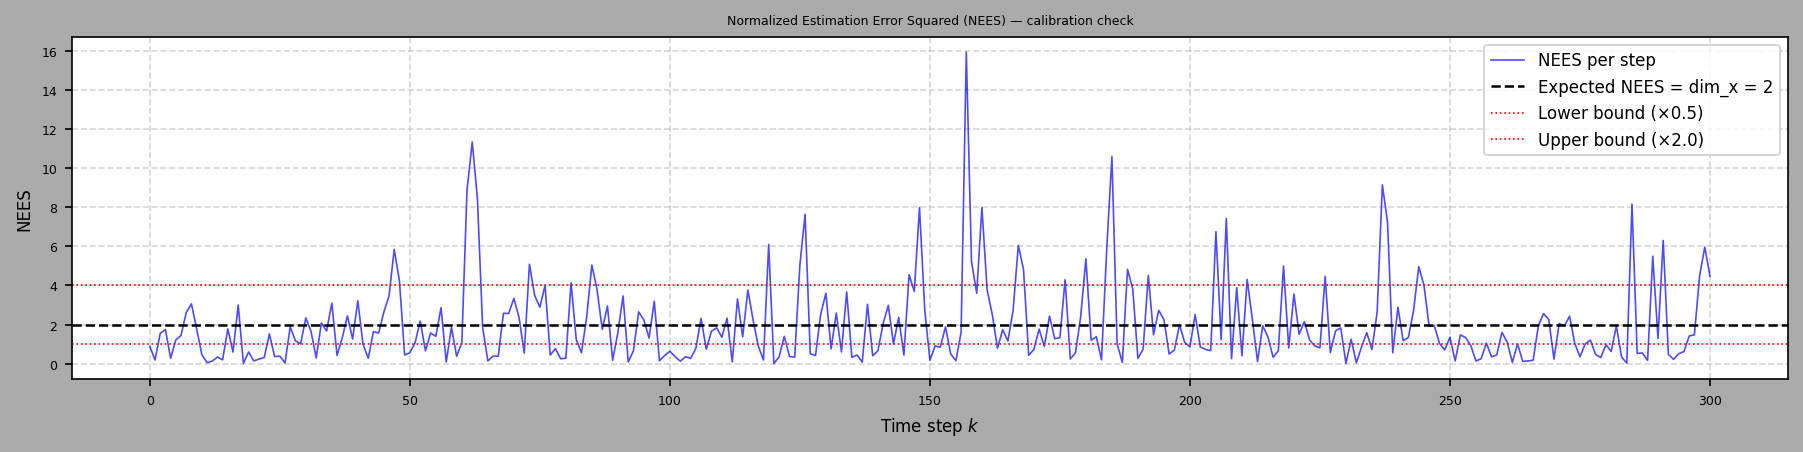

In [22]:
# NEES over time — visual calibration check
fig, ax = plt.subplots(figsize=(12, 3))
ax.plot(nees_steps, color="C2", lw=0.8, alpha=0.7, label="NEES per step")
ax.axhline(dim_x, color="black", lw=1.2, linestyle="--", label=f"Expected NEES = dim_x = {dim_x}")
ax.axhline(0.5 * dim_x, color="C3", lw=0.8, linestyle=":", label="Lower bound (×0.5)")
ax.axhline(2.0 * dim_x, color="C3", lw=0.8, linestyle=":", label="Upper bound (×2.0)")
ax.set_xlabel("Time step $k$")
ax.set_ylabel("NEES")
ax.set_title("Normalized Estimation Error Squared (NEES) — calibration check")
ax.legend(fontsize=8)
ax.grid(True, linestyle="--", alpha=0.5)
plt.tight_layout()
plt.show()

---
## 7. Comparing Filters: Linear PKF vs EPKF vs UPKF

For a **linear model**, the Linear PKF is the optimal filter (equivalent to the standard Kalman Filter).
The EPKF and UPKF are approximations, but should produce identical results here.

We simulate data once and pass the same trajectory to all three filters.

In [23]:
N_cmp = 500

# --- Build ParamLinear (for Linear_PKF) ---
p = ModelFactoryLinear.create("model_x2_y2_AQ_classic").get_params().copy()
dim_x_c = p.pop("dim_x")
dim_y_c = p.pop("dim_y")
param_lin = ParamLinear(0, dim_x_c, dim_y_c, **p)

# --- Build ParamNonLinear (for EPKF / UPKF) ---
p2 = ModelFactoryLinear.create("model_x2_y2_AQ_classic").get_params().copy()
p2.pop("dim_x")
p2.pop("dim_y")
param_nl = ParamNonLinear(0, dim_x_c, dim_y_c, **p2)

# --- Simulate data using the linear PKF's internal generator ---
ref_pkf  = Linear_PKF(param_lin, sKey=SEED)
sim_data = ref_pkf.simulate_N_data(N_cmp)   # list of (k, x_true, y_obs)
print(f"Simulated {len(sim_data)} steps — first entry: k={sim_data[0][0]}, x={sim_data[0][1].flatten()}")

Simulated 501 steps — first entry: k=0, x=[-0.69531929  1.42474026]


In [ ]:
# --- Run each filter on the same data ---
pkf_cmp   = Linear_PKF(param_lin, sKey=SEED)
epkf_cmp  = NonLinear_EPKF(param_nl, sKey=SEED)
upkf_cmp  = NonLinear_UPKF(param_nl, sigmaSet="wan2000", sKey=SEED)

res_pkf  = pkf_cmp.process_N_data(N=None, data_generator=iter(sim_data))
res_epkf = epkf_cmp.process_N_data(N=None, data_generator=iter(sim_data))
res_upkf = upkf_cmp.process_N_data(N=None, data_generator=iter(sim_data))

print(f"PKF  results: {len(res_pkf)}")
print(f"EPKF results: {len(res_epkf)}")
print(f"UPKF results: {len(res_upkf)}")

In [ ]:
def extract_update(results):
    """Extract (x_true, x_update) arrays from process_N_data results."""
    xu = np.array([r[4].flatten() for r in results if r[4] is not None])   # (M, dim_x)
    M  = len(xu)
    xt = np.array([r[1].flatten() for r in results[:M]])                    # (M, dim_x)
    return xt, xu

xt_pkf,  xu_pkf  = extract_update(res_pkf)
xt_epkf, xu_epkf = extract_update(res_epkf)
xt_upkf, xu_upkf = extract_update(res_upkf)

# MSE per filter
def mse(xt, xu):
    return float(np.mean((xt - xu) ** 2))

print("MSE comparison (lower is better):")
print(f"  Linear PKF : {mse(xt_pkf,  xu_pkf):.6f}")
print(f"  EPKF       : {mse(xt_epkf, xu_epkf):.6f}")
print(f"  UPKF       : {mse(xt_upkf, xu_upkf):.6f}")

In [ ]:
# --- Visual comparison on a time window ---
T_WIN = slice(0, 100)   # first 100 steps
t_win = np.arange(1, N_cmp + 1)[T_WIN]

fig, axes = plt.subplots(dim_x_c, 1, figsize=(13, 3.5 * dim_x_c), sharex=True)
if dim_x_c == 1:
    axes = [axes]

for i in range(dim_x_c):
    ax = axes[i]
    ax.plot(t_win, xt_pkf[T_WIN, i],   color="black", lw=1.0, label="Ground truth")
    ax.plot(t_win, xu_pkf[T_WIN, i],   color="C0",    lw=1.5, linestyle="-",  label="Linear PKF")
    ax.plot(t_win, xu_epkf[T_WIN, i],  color="C1",    lw=1.2, linestyle="--", label="EPKF")
    ax.plot(t_win, xu_upkf[T_WIN, i],  color="C2",    lw=1.0, linestyle=":",  label="UPKF (wan2000)")
    ax.set_ylabel(f"$x_{i+1}$")
    ax.legend(loc="upper right", fontsize=8)
    ax.grid(True, linestyle="--", alpha=0.5)

axes[-1].set_xlabel("Time step $k$")
fig.suptitle("Filter comparison on a linear model — PKF, EPKF, UPKF", y=1.01)
plt.tight_layout()
plt.show()

In [ ]:
# --- Bar chart of per-component MSE ---
labels = [f"$x_{i+1}$" for i in range(dim_x_c)]
mse_pkf  = [float(np.mean((xt_pkf[:, i]  - xu_pkf[:, i])  ** 2)) for i in range(dim_x_c)]
mse_epkf = [float(np.mean((xt_epkf[:, i] - xu_epkf[:, i]) ** 2)) for i in range(dim_x_c)]
mse_upkf = [float(np.mean((xt_upkf[:, i] - xu_upkf[:, i]) ** 2)) for i in range(dim_x_c)]

x = np.arange(dim_x_c)
w = 0.25

fig, ax = plt.subplots(figsize=(6, 4))
ax.bar(x - w,   mse_pkf,  w, label="Linear PKF", color="C0")
ax.bar(x,       mse_epkf, w, label="EPKF",       color="C1")
ax.bar(x + w,   mse_upkf, w, label="UPKF",       color="C2")
ax.set_xticks(x)
ax.set_xticklabels(labels)
ax.set_ylabel("MSE")
ax.set_title("Per-component MSE by filter")
ax.legend()
ax.grid(True, axis="y", linestyle="--", alpha=0.5)
plt.tight_layout()
plt.show()

---
## 8. Going Further

| Task | How |
|------|-----|
| Try a pairwise model | `ModelFactoryLinear.create("model_x2_y2_AQ_pairwise")` |
| Try a nonlinear model | `ModelFactoryNonLinear.create("model_x2_y1_classic")` |
| Use the PPF particle filter | `from prg import NonLinear_PPF` — requires `ParamNonLinear` and a pairwise model |
| Load data from a CSV file | Use `run_simulator` CLI to generate, then pass via `data_generator` |
| Save and reload history | `pkf.history.save_pickle("run.pkl")` / `HistoryTracker.load_pickle("run.pkl")` |
| Run from the command line | `awesomepkf-pkf --linearModelName model_x2_y2_AQ_classic --N 500 --plot` |

See `tutorial_02_nonlinear_models.ipynb` for nonlinear models and the PPF/PF filters.